In [4]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent / "src"))

import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from utils.splits import check_split


pd.set_option("display.max_columns", None)


df = pd.read_excel("../data/Baza-walidacyjna1.xlsx")
df.head()

,Szpital,ID,wiek,PSA,data mri,data operacji,PSAdensity,iT,DRE (0-prawidłowe; 1-nieprawidłowe),MRI prostate vol,MRI Pirads IL,MRI EPE (naciek poza torebke),MRI EPE L,MRI EPE P,MRI SVI (pecherzyki),MRI SVI L,MRI SVI P,MRI SIZE INDEX LESION,MAX Bx ISUP Grade L,MAX % L,ilość + wycinków L CEL,ilość + wycinków L REG,ilość + wycinków L SYS,SUMA WYCINKÓW L,MAX Bx ISUP Grade P,MAX % P,ilość + wycinków P CEL,ilość + wycinków P REG,ilość + wycinków P SYS,SUMA WYCINKÓW P,ISUP RP,ISUP RP P,ISUP RP L,SM +,N +,EPE RP,strona EPE RP,EPE RP L,EPE RP P,SVI RP,strona SVI RP,SVI RP L,SVI RP P,TNM
0,Szwajcary,277,73.0,12.00,NaT,NaT,0.480000,2b,0.0,25.0,4.0,0.0,0.0,0.0,NaN,NaN,NaN,5.0,2.0,NaN,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,1.0,NaN,0.0,NaN,0,0,0.0,NaN,NaN,NaN,2
1,Szwajcary,62,56.0,3.50,NaT,NaT,0.102941,2c,0.0,34.0,4.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,1.0,0.60,2z4,NaN,1z6,NaN,1.0,0.34,2z4,NaN,0z6,NaN,2.0,NaN,NaN,0.0,NaN,0.0,NaN,0,0,0.0,NaN,NaN,NaN,2
2,Szwajcary,64,76.0,8.82,NaT,NaT,0.122500,2b,1.0,72.0,4.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,2.0,0.52,3z6,NaN,0z4,NaN,1.0,0.10,NaN,NaN,1z4,NaN,2.0,NaN,NaN,0.0,NaN,0.0,NaN,0,0,0.0,NaN,NaN,NaN,2
3,Szwajcary,65,56.0,5.50,NaT,NaT,0.152778,2c,1.0,36.0,4.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,3.0,40.00,5z6,NaN,2z4,NaN,3.0,40.00,5z6,NaN,0z4,NaN,3.0,NaN,NaN,0.0,0.0,1.0,P,0,1,1.0,NaN,NaN,NaN,3a
4,Szwajcary,66,68.0,10.80,NaT,NaT,0.225000,3a,0.0,48.0,5.0,1.0,0.0,1.0,NaN,NaN,NaN,NaN,2.0,0.62,4z6,NaN,0z6,NaN,0.0,0.00,NaN,NaN,0z6,NaN,1.0,NaN,NaN,0.0,NaN,0.0,NaN,0,0,0.0,NaN,NaN,NaN,2


# Standardize naming convention
Columns:
- szpital
- ID
- wiek
- PSA
- data mri
- data operacji
- PSA density
- iT
- DRE
- MRI prostate volume
- MRI PIRADS
- MRI EPE
- MRI EPE L
- MRI EPE R
- MRI SVI
- MRI SVI L
- MRI SVI R
- MRI lesion size
- Bx ISUP L
- Bx max % L
- Bx wycinki L CEL
- Bx wycinki L REG
- Bx wycinki L SYS
- Bx wycinki L
- Bx ISUP R
- Bx max % R
- Bx wycinki R CEL
- Bx wycinki R REG
- Bx wycinki R SYS
- Bx wycinki R
- RP ISUP
- RP ISUP L
- RP ISUP R
- RP SM+
- RP N+
- RP EPE
- RP EPE strona
- RP EPE L
- RP EPE R
- RP SVI
- RP SVI strona
- RP SVI L
- RP SVI R
- RP TNM

In [5]:
names = {
    "Szpital": "szpital",
    "PSAdensity": "PSA density",
    "DRE (0-prawidłowe; 1-nieprawidłowe)": "DRE",
    "MRI prostate vol": "MRI prostate volume",
    "MRI Pirads IL": "MRI PIRADS",
    "MRI EPE (naciek poza torebke)": "MRI EPE",
    "MRI EPE L": "MRI EPE L",
    "MRI EPE P": "MRI EPE P",
    "MRI SVI (pecherzyki)": "MRI SVI",
    "MRI SVI L": "MRI SVI L",
    "MRI SVI P": "MRI SVI P",
    "MRI SIZE INDEX LESION": "MRI lesion size",
    "MAX Bx ISUP Grade L": "Bx ISUP L",
    "MAX % L": "Bx max % L",
    "ilość\xa0+ wycinków L CEL": "Bx wycinki L CEL",
    "ilość\xa0+ wycinków L REG": "Bx wycinki L REG",
    "ilość\xa0+ wycinków L SYS": "Bx wycinki L SYS",
    "SUMA WYCINKÓW L": "Bx wycinki L",
    "MAX Bx ISUP Grade P": "Bx ISUP R",
    "MAX % P": "Bx max % R",
    "ilość\xa0+ wycinków P CEL": "Bx wycinki R CEL",
    "ilość\xa0+ wycinków P REG": "Bx wycinki R REG",
    "ilość\xa0+ wycinków P SYS": "Bx wycinki R SYS",
    "SUMA WYCINKÓW P": "Bx wycinki R",
    "ISUP RP": "RP ISUP",
    "ISUP RP P": "RP ISUP R",
    "ISUP RP L": "RP ISUP L",
    "SM +": "RP SM+",
    "N +": "RP N+",
    "EPE RP": "RP EPE",
    "strona EPE RP": "RP EPE strona",
    "EPE RP L": "RP EPE L",
    "EPE RP P": "RP EPE P",
    "SVI RP": "RP SVI",
    "strona SVI RP": "RP SVI strona",
    "SVI RP L": "RP SVI L",
    "SVI RP P": "RP SVI P",
    "TNM": "RP TNM",
}

df.rename(columns=names, inplace=True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1377 entries, 0 to 1376
Data columns (total 44 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   szpital              1377 non-null   object        
 1   ID                   1377 non-null   object        
 2   wiek                 1362 non-null   float64       
 3   PSA                  1361 non-null   float64       
 4   data mri             601 non-null    datetime64[ns]
 5   data operacji        975 non-null    datetime64[ns]
 6   PSA density          1278 non-null   float64       
 7   iT                   1377 non-null   object        
 8   DRE                  531 non-null    float64       
 9   MRI prostate volume  1281 non-null   float64       
 10  MRI PIRADS           1264 non-null   float64       
 11  MRI EPE              1270 non-null   float64       
 12  MRI EPE L            1271 non-null   float64       
 13  MRI EPE P            1270 non-nul

In [7]:
df.columns.to_list()

['szpital',
 'ID',
 'wiek',
 'PSA',
 'data mri',
 'data operacji',
 'PSA density',
 'iT',
 'DRE',
 'MRI prostate volume',
 'MRI PIRADS',
 'MRI EPE',
 'MRI EPE L',
 'MRI EPE P',
 'MRI SVI',
 'MRI SVI L',
 'MRI SVI P',
 'MRI lesion size',
 'Bx ISUP L',
 'Bx max % L',
 'Bx wycinki L CEL',
 'Bx wycinki L REG',
 'Bx wycinki L SYS',
 'Bx wycinki L',
 'Bx ISUP R',
 'Bx max % R',
 'Bx wycinki R CEL',
 'Bx wycinki R REG',
 'Bx wycinki R SYS',
 'Bx wycinki R',
 'RP ISUP',
 'RP ISUP R',
 'RP ISUP L',
 'RP SM+',
 'RP N+',
 'RP EPE',
 'RP EPE strona',
 'RP EPE L',
 'RP EPE P',
 'RP SVI',
 'RP SVI strona',
 'RP SVI L',
 'RP SVI P',
 'RP TNM']

# Czas do operacji (może przydać się do upgradingu)

In [10]:
df["days_to_surgery"] = (df["data operacji"] - df["data mri"]).dt.days

In [11]:
df["days_to_surgery"].describe()

count     565.000000
mean      114.030088
std       143.978294
min     -2010.000000
25%        61.000000
50%        92.000000
75%       153.000000
max       851.000000
Name: days_to_surgery, dtype: float64

In [13]:
df[df["days_to_surgery"] < 0]

,szpital,ID,wiek,PSA,data mri,data operacji,PSA density,iT,DRE,MRI prostate volume,MRI PIRADS,MRI EPE,MRI EPE L,MRI EPE P,MRI SVI,MRI SVI L,MRI SVI P,MRI lesion size,Bx ISUP L,Bx max % L,Bx wycinki L CEL,Bx wycinki L REG,Bx wycinki L SYS,Bx wycinki L,Bx ISUP R,Bx max % R,Bx wycinki R CEL,Bx wycinki R REG,Bx wycinki R SYS,Bx wycinki R,RP ISUP,RP ISUP R,RP ISUP L,RP SM+,RP N+,RP EPE,RP EPE strona,RP EPE L,RP EPE P,RP SVI,RP SVI strona,RP SVI L,RP SVI P,RP TNM,days_to_surgery
458,Otwock,a100,67.0,15.70,2020-11-01,2020-02-01,0.320408,2c,NaN,49.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0,1.0,25.0,3na5,NaN,1na4,NaN,1.0,25.0,3na5,NaN,0,NaN,2.0,2.0,2.0,0.0,0.0,0.0,NaN,0,0,0.0,NaN,0.0,0.0,2c,-274.0
843,Otwock,a487,63.0,5.60,2016-06-01,2016-05-01,0.160000,2b,NaN,35.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,12.0,0.0,0.0,NaN,NaN,0,NaN,2.0,NaN,NaN,NaN,1wyc,NaN,2.0,2.0,2.0,0.0,0.0,1.0,NaN,1,0,0.0,NaN,0.0,0.0,3a,-31.0
880,Otwock,a524,60.0,2.80,2020-01-01,2014-07-01,0.077778,2a,NaN,36.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,0.0,0.0,NaN,NaN,0,NaN,2.0,75.0,NaN,NaN,5na5,NaN,2.0,2.0,2.0,0.0,0.0,0.0,NaN,0,0,0.0,NaN,0.0,0.0,2c,-2010.0
1216,Otwock,a867,70.0,7.76,2020-04-13,2019-07-23,0.129333,2c,NaN,60.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,4.0,70.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,1na1,NaN,3.0,1.0,3.0,0.0,0.0,0.0,NaN,0,0,0.0,NaN,0.0,0.0,2c,-265.0
1249,Otwock,a900,NaN,13.80,2018-10-10,2017-04-18,0.281633,2b,NaN,49.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,18.0,1.0,60.0,NaN,NaN,4na6,NaN,0.0,0.0,NaN,NaN,0,NaN,5.0,5.0,5.0,0.0,0.0,1.0,NaN,1,0,0.0,NaN,0.0,0.0,3a,-540.0
1303,Otwock,a955,64.0,6.88,2016-09-28,2016-01-03,0.312727,2b,NaN,22.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,11.0,0.0,0.0,NaN,NaN,0,NaN,1.0,30.0,NaN,NaN,2na6,NaN,2.0,2.0,2.0,0.0,0.0,0.0,NaN,0,0,0.0,NaN,0.0,0.0,2c,-269.0
1312,Otwock,a964,64.0,10.85,2015-12-17,2015-01-04,0.319118,3a,1.0,34.0,5.0,1.0,0.0,1.0,0.0,0.0,0.0,19.0,0.0,0.0,NaN,NaN,0,NaN,1.0,80.0,NaN,NaN,NaN,NaN,2.0,2.0,0.0,0.0,0.0,0.0,NaN,0,0,0.0,NaN,0.0,0.0,2c,-347.0
1332,Otwock,a986,58.0,5.67,2020-12-23,2020-04-01,0.091452,2b,1.0,62.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,2.0,NaN,NaN,NaN,3na3,NaN,0.0,0.0,NaN,NaN,0,NaN,3.0,3.0,3.0,0.0,0.0,1.0,NaN,1,0,0.0,NaN,0.0,0.0,2c,-266.0


### analizując czas do operacji, powinnismy wyrzucic przypadki ktore mają ujemny czas czekania do operacji (powyżej)

# Missing values

In [ ]:
# temp = df.drop(
#     columns=[
#         "data mri",
#         "data operacji",
#         "iT",
#         "DRE",
#         "MRI EPE L",
#         "MRI EPE P",
#         "MRI SVI L",
#         "MRI SVI P",
#         "Bx wycinki L CEL",
#         "Bx wycinki L REG",
#         "Bx wycinki L SYS",
#         "Bx wycinki L",
#         "Bx wycinki R CEL",
#         "Bx wycinki R REG",
#         "Bx wycinki R SYS",
#         "Bx wycinki R",
#         "RP ISUP",
#         "RP ISUP R",
#         "RP ISUP L",
#         "RP SM+",
#         "RP N+",
#         "RP EPE",
#         "RP EPE strona",
#         "RP SVI strona",
#     ]
# )
# temp.dropna().info()

<class 'pandas.core.frame.DataFrame'>
Index: 528 entries, 363 to 1376
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   szpital              528 non-null    object 
 1   ID                   528 non-null    object 
 2   wiek                 528 non-null    float64
 3   PSA                  528 non-null    float64
 4   PSA density          528 non-null    float64
 5   MRI prostate volume  528 non-null    float64
 6   MRI PIRADS           528 non-null    float64
 7   MRI EPE              528 non-null    float64
 8   MRI SVI              528 non-null    float64
 9   MRI lesion size      528 non-null    float64
 10  Bx ISUP L            528 non-null    float64
 11  Bx max % L           528 non-null    float64
 12  Bx ISUP R            528 non-null    float64
 13  Bx max % R           528 non-null    float64
 14  RP EPE L             528 non-null    int64  
 15  RP EPE P             528 non-null    int64

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1377 entries, 0 to 1376
Data columns (total 45 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   szpital              1377 non-null   object        
 1   ID                   1377 non-null   object        
 2   wiek                 1362 non-null   float64       
 3   PSA                  1361 non-null   float64       
 4   data mri             601 non-null    datetime64[ns]
 5   data operacji        975 non-null    datetime64[ns]
 6   PSA density          1278 non-null   float64       
 7   iT                   1377 non-null   object        
 8   DRE                  531 non-null    float64       
 9   MRI prostate volume  1281 non-null   float64       
 10  MRI PIRADS           1264 non-null   float64       
 11  MRI EPE              1270 non-null   float64       
 12  MRI EPE L            1271 non-null   float64       
 13  MRI EPE P            1270 non-nul

# Cores 

In [34]:
df_copy = df.copy()

In [35]:
df["Bx wycinki R REG"].unique().tolist()

[nan, '2z6', '6z6', '0z6', '0z4', '2z5', '3z3', '1na2', '2na3', '4na4', '4z6']

In [36]:
import re


def clean_wycinki_value(value):
    if pd.isna(value):
        return pd.NA

    s = str(value).strip().lower().replace("\xa0", " ")

    if '?' in s: # jezeli '?' wtedy uznajemy ze calkowicie nie wiadomo
        return pd.NA
    
    if '.' in s: # jezeli '.' wtedy pomijamy (w niektorych przypadkach podana jest wartosc procentowa)
        return pd.NA
    
    nums = re.findall(r"\d+", s)

    if len(nums) >= 2:
        x1, x2 = nums[0], nums[1]
    elif len(nums) == 1:
        x1 = x2 = nums[0]
    else:
        return pd.NA

    return f"{int(x1)} {int(x2)}"

In [37]:
wycinki_cols = [
    "Bx wycinki L CEL",
    "Bx wycinki L REG",
    "Bx wycinki L SYS",
    "Bx wycinki R CEL",
    "Bx wycinki R REG",
    "Bx wycinki R SYS",
]

for col in wycinki_cols:
    df_copy[col] = df_copy[col].apply(clean_wycinki_value)

df_copy[wycinki_cols].head(10)

,Bx wycinki L CEL,Bx wycinki L REG,Bx wycinki L SYS,Bx wycinki R CEL,Bx wycinki R REG,Bx wycinki R SYS
0,6 6,<NA>,<NA>,<NA>,<NA>,<NA>
1,2 4,<NA>,1 6,2 4,<NA>,0 6
2,3 6,<NA>,0 4,<NA>,<NA>,1 4
3,5 6,<NA>,2 4,5 6,<NA>,0 4
4,4 6,<NA>,0 6,<NA>,<NA>,0 6
5,5 6,<NA>,0 6,5 6,<NA>,0 6
6,2 6,<NA>,0 6,<NA>,<NA>,2 6
7,4 6,<NA>,0 6,4 6,<NA>,1 6
8,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
9,5 14,2 2,<NA>,5 14,<NA>,<NA>


In [38]:
def sum_wycinki(row, cols):
    total_first = 0
    total_second = 0
    is_valid = False
    for col in cols:
        value = row[col]
        if pd.isna(value):
            continue
        parts = value.split()
        if len(parts) == 2:
            first, second = int(parts[0]), int(parts[1])
            total_first += first
            total_second += second
            is_valid = True
    if is_valid:
        return f"{total_first} {total_second}"
    else:
        return pd.NA


In [39]:
sum_wycinki_cols_L = ["Bx wycinki L CEL", "Bx wycinki L REG", "Bx wycinki L SYS"]
sum_wycinki_cols_R = ["Bx wycinki R CEL", "Bx wycinki R REG", "Bx wycinki R SYS"]

df_copy["Bx wycinki L"] = df_copy.apply(sum_wycinki, axis=1, cols=sum_wycinki_cols_L)
df_copy["Bx wycinki R"] = df_copy.apply(sum_wycinki, axis=1, cols=sum_wycinki_cols_R)

In [42]:
df_copy["Bx wycinki R"].unique().tolist()

[<NA>,
 '2 10',
 '1 4',
 '5 10',
 '0 6',
 '5 12',
 '2 6',
 '5 14',
 '1 10',
 '9 9',
 '0 3',
 '6 6',
 '4 10',
 '2 4',
 '1 12',
 '6 12',
 '1 9',
 '3 14',
 '10 10',
 '12 14',
 '1 14',
 '7 14',
 '1 6',
 '2 16',
 '1 8',
 '6 10',
 '2 3',
 '4 5',
 '3 3',
 '4 8',
 '0 0',
 '6 9',
 '5 5',
 '4 4',
 '3 4',
 '2 5',
 '2 2',
 '9 11',
 '8 9',
 '7 8',
 '4 6',
 '1 3',
 '2 1',
 '5 8',
 '7 9',
 '8 10',
 '8 8',
 '5 6',
 '3 10',
 '0 4',
 '8 14',
 '2 12',
 '5 11',
 '8 12',
 '1 2',
 '6 16',
 '9 12',
 '12 12',
 '4 12',
 '3 8',
 '9 10',
 '1 1',
 '0 2',
 '7 7',
 '3 7',
 '9 15',
 '6 7',
 '1 5',
 '2 7',
 '0 5',
 '3 6',
 '3 9',
 '1 7',
 '3 5',
 '0 7',
 '2 8',
 '5 7',
 '2 15',
 '4 9',
 '4 7',
 '7 10',
 '6 8',
 '0 13',
 '0 1',
 '3 11',
 '3 20',
 '7 11',
 '70 70']

In [81]:
df_copy[df_copy["Bx wycinki R %"] > 100]

,szpital,ID,wiek,PSA,data mri,data operacji,PSA density,iT,DRE,MRI prostate volume,MRI PIRADS,MRI EPE,MRI EPE L,MRI EPE P,MRI SVI,MRI SVI L,MRI SVI P,MRI lesion size,Bx ISUP L,Bx max % L,Bx wycinki L CEL,Bx wycinki L REG,Bx wycinki L SYS,Bx wycinki L,Bx ISUP R,Bx max % R,Bx wycinki R CEL,Bx wycinki R REG,Bx wycinki R SYS,Bx wycinki R,RP ISUP,RP ISUP R,RP ISUP L,RP SM+,RP N+,RP EPE,RP EPE strona,RP EPE L,RP EPE P,RP SVI,RP SVI strona,RP SVI L,RP SVI P,RP TNM,days_to_surgery,Bx wycinki R positive_cores,Bx wycinki R total_cores,Bx wycinki L positive_cores,Bx wycinki L total_cores,Bx wycinki L %,Bx wycinki R %


In [80]:
df_copy.loc[71, ["Bx wycinki R SYS", "Bx wycinki R", "Bx wycinki R %"]] = pd.NA

In [82]:
r_wycinki_split = df_copy["Bx wycinki R"].str.split(" ", expand=True)

df_copy["Bx wycinki R positive_cores"] = r_wycinki_split[0].astype("Int64")
df_copy["Bx wycinki R total_cores"] = r_wycinki_split[1].astype("Int64")

l_wycinki_split = df_copy["Bx wycinki L"].str.split(" ", expand=True)
df_copy["Bx wycinki L positive_cores"] = l_wycinki_split[0].astype("Int64")
df_copy["Bx wycinki L total_cores"] = l_wycinki_split[1].astype("Int64")


<Axes: ylabel='Frequency'>

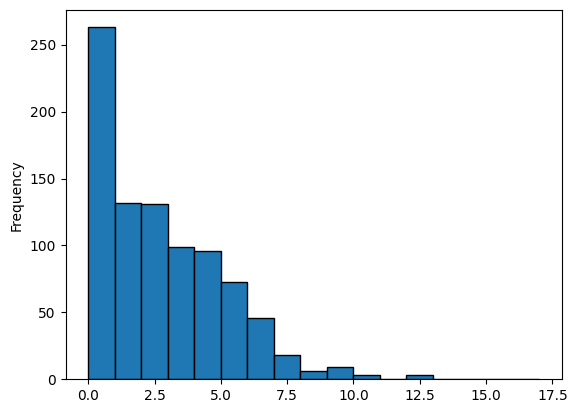

In [83]:
df_copy["Bx wycinki R positive_cores"].plot(kind="hist", bins=range(0, 18), edgecolor="black")

<Axes: ylabel='Frequency'>

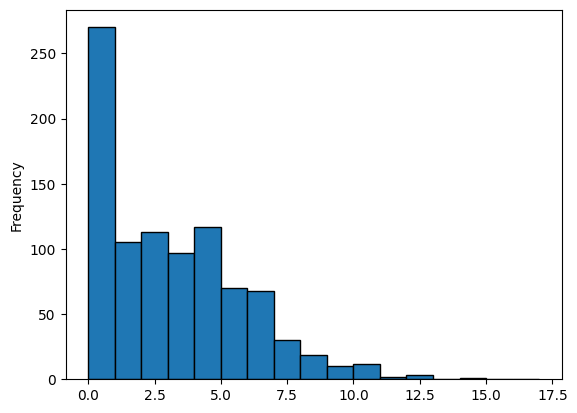

In [84]:
df_copy["Bx wycinki L positive_cores"].plot(kind="hist", bins=range(0, 18), edgecolor="black")

In [85]:
df_copy["Bx wycinki L %"] = (df_copy["Bx wycinki L positive_cores"] / df_copy["Bx wycinki L total_cores"]) * 100
df_copy["Bx wycinki R %"] = (df_copy["Bx wycinki R positive_cores"] / df_copy["Bx wycinki R total_cores"]) * 100

<Axes: ylabel='Frequency'>

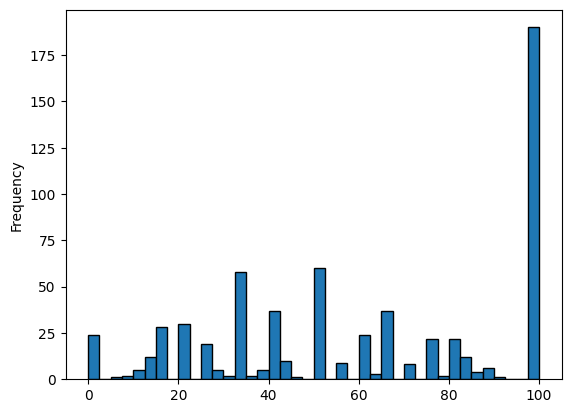

In [86]:
df_copy["Bx wycinki R %"].plot(kind="hist", bins=40, edgecolor="black")

<Axes: ylabel='Frequency'>

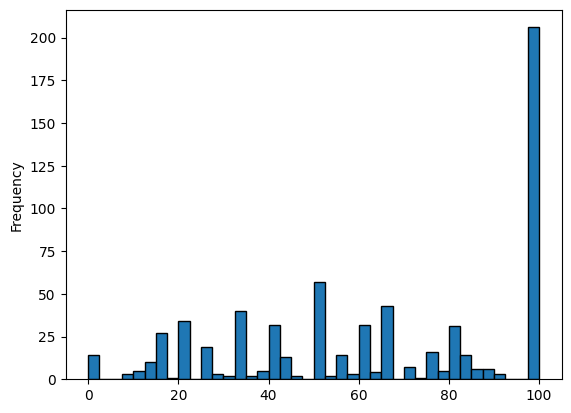

In [87]:
df_copy["Bx wycinki L %"].plot(kind="hist", bins=40, edgecolor="black")

In [88]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1377 entries, 0 to 1376
Data columns (total 51 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   szpital                      1377 non-null   object        
 1   ID                           1377 non-null   object        
 2   wiek                         1362 non-null   float64       
 3   PSA                          1361 non-null   float64       
 4   data mri                     601 non-null    datetime64[ns]
 5   data operacji                975 non-null    datetime64[ns]
 6   PSA density                  1278 non-null   float64       
 7   iT                           1377 non-null   object        
 8   DRE                          531 non-null    float64       
 9   MRI prostate volume          1281 non-null   float64       
 10  MRI PIRADS                   1264 non-null   float64       
 11  MRI EPE                      1270 non-null 

# Data split

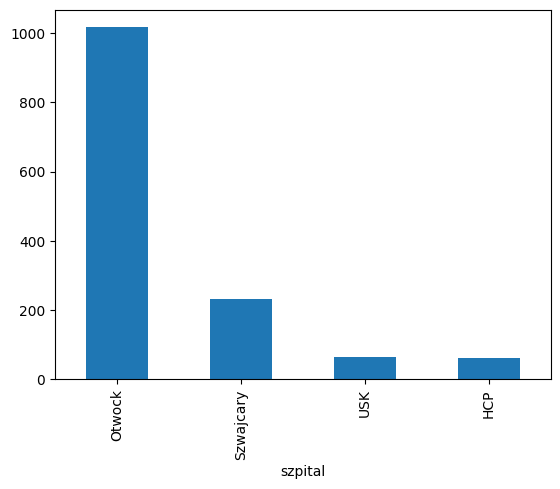

In [89]:
df["szpital"].value_counts().plot(kind="bar")
plt.show()

In [91]:
df_train = df[df["szpital"].isin(["Otwock", "USK", "HCP"])]
df_test = df[df["szpital"].isin(["Szwajcary"])]
print(f"Train set size: {len(df_train)} {len(df_train) / len(df) * 100:.2f}%")
print(f"Test set size: {len(df_test)} {len(df_test) / len(df) * 100:.2f}%")

Train set size: 1144 83.08%
Test set size: 233 16.92%


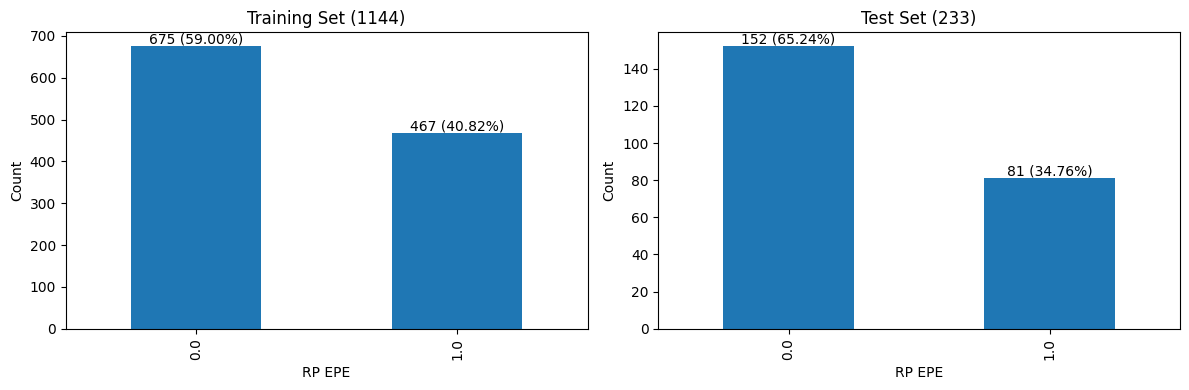

In [ ]:
# dla EPE mozemy zastosowac Szwajcary jakos test split, podobna dystrybucja targetu
check_split(df_train, df_test, "RP EPE")

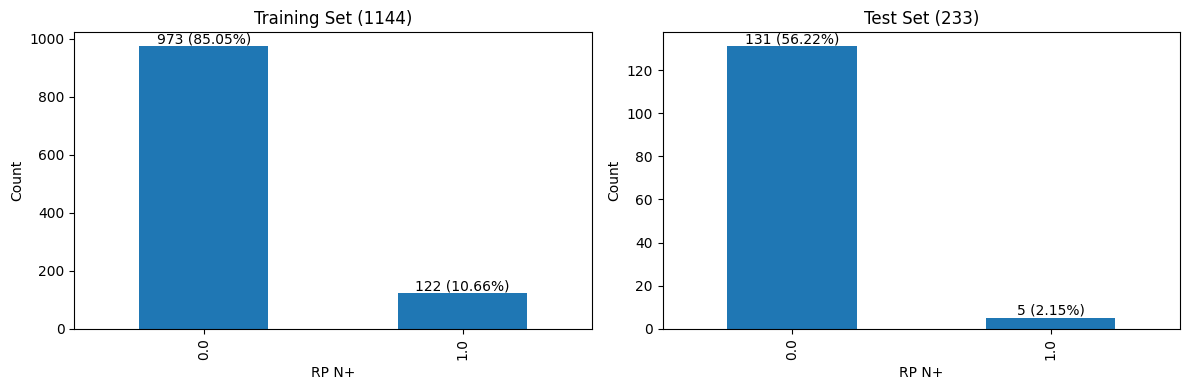

In [ ]:
# dla N+ mamy duzy imbalance, wiec nie mozemy uzyc takiego samego splitu, czy chcemy to rozbijać?
check_split(df_train, df_test, "RP N+")